In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style('darkgrid')
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
""" Semilla """
seed = 99

## DATOS ##

data=pd.read_csv('SAheartbis.csv')

data['chd'] = data['chd'].map({'Si': 1, 'No': 0})

data = data.drop(columns=["Unnamed: 0"]) ## depende de la versión la exporta

y=pd.DataFrame(data["chd"])
X=data.drop(columns="chd")





In [3]:

# performing the train test and validation split
train_ratio = 0.70 ### entrenamos los modelos iniciales
validation_ratio = 0.20 ## entrenamos el stacking
test_ratio = 0.10 ## test real para medir la precision del modelo

##  1 - test_ratio es realmente la cantidad que estamos usando para entrenar: modelos iniciales + stacking
[X_train, X_test, y_train, y_test] = train_test_split(X, y, test_size = 1 - train_ratio, random_state = 101)

####

# performing test validation split
X_val, X_test, y_val, y_test = train_test_split(
	X_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio))

In [4]:
display(X_train.head())
display(y_train.head())

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,famhist_Present
93,-0.992806,0.079413,-0.382045,-0.829453,0.091375,-0.212423,-0.356351,0.423760,0
213,-0.309016,-0.792417,-1.817753,-0.516803,0.907127,0.167704,-0.696983,0.697861,0
278,-1.188175,-0.792417,-1.020138,-2.022154,-0.826346,-1.937250,-0.696983,-1.837577,0
225,0.228247,0.306089,0.057851,-0.233745,0.499251,-0.321709,0.068519,-0.055918,0
121,-0.895122,-0.487277,0.729782,-0.635172,0.703189,-0.046117,-0.348990,-1.015273,0


,chd
93,1
213,0
278,0
225,0
121,0


In [5]:
display(X_val.head())
display(y_val.head())

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,famhist_Present
36,0.081721,0.057617,1.247023,-0.045898,-0.622408,0.312628,0.806623,-0.741171,0
56,-0.992806,-0.792417,-0.846112,-1.188421,-0.418470,-0.526028,-0.565310,-1.015273,0
114,-1.090491,6.007857,-0.759100,-1.340243,-0.622408,-1.578505,1.309188,1.109013,0
24,0.179405,3.174409,-0.193518,-0.132102,0.805158,0.034660,-0.696983,0.492285,0
98,-0.797438,-0.094953,3.180636,1.280612,0.193344,0.243730,-0.696983,0.560810,1


,chd
36,0
56,0
114,1
24,0
98,1


In [6]:
import pandas as pd
from sklearn.metrics import mean_squared_error

# importing machine learning models for prediction
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.linear_model import LinearRegression,LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix
# importing train test split
from sklearn.model_selection import train_test_split



model_1 = SVC(kernel='linear', probability =True)
model_2 = xgb.XGBClassifier()
model_3 = RandomForestClassifier()
# training all the model on the train dataset


# training first model
model_1.fit(X_train, y_train)
val_pred_1 = model_1.predict_proba(X_val)[:, 1]  # Select probability of class 1
test_pred_1 = model_1.predict_proba(X_test)[:, 1]  # Select probability of class 1

# converting to dataframe
val_pred_1 = pd.DataFrame(val_pred_1, columns=['model1'])  # Specify column name
test_pred_1 = pd.DataFrame(test_pred_1, columns=['model1'])  # Specify column name


# training second model
model_2.fit(X_train, y_train)
val_pred_2 = model_2.predict_proba(X_val)[:, 1]  # Select probability of class 1
test_pred_2 = model_2.predict_proba(X_test)[:, 1]  # Select probability of class 1

# converting to dataframe
val_pred_2 = pd.DataFrame(val_pred_2, columns=['model2'])  # Specify column name
test_pred_2 = pd.DataFrame(test_pred_2, columns=['model2'])  # Specify column name


# training first model
model_3.fit(X_train, y_train)
val_pred_3 = model_3.predict_proba(X_val)[:, 1]  # Select probability of class 1
test_pred_3 = model_3.predict_proba(X_test)[:, 1]  # Select probability of class 1

# converting to dataframe
val_pred_3 = pd.DataFrame(val_pred_3, columns=['model3'])  # Specify column name
test_pred_3 = pd.DataFrame(test_pred_3, columns=['model3'])  # Specify column name



# concatenating validation dataset along with all the predicted validation data (meta features)
df_val = pd.concat([val_pred_1, val_pred_2, val_pred_3], axis=1)
df_test = pd.concat([test_pred_1, test_pred_2, test_pred_3], axis=1)





display(df_val.head())
display(df_test.head())




,model1,model2,model3
0,0.164691,0.013872,0.34
1,0.092507,0.225304,0.09
2,0.475707,0.688399,0.54
3,0.559176,0.836783,0.51
4,0.672644,0.972876,0.72


,model1,model2,model3
0,0.386531,0.440147,0.48
1,0.410819,0.737456,0.42
2,0.544014,0.983521,0.75
3,0.112886,0.016374,0.34
4,0.590930,0.936900,0.64


In [7]:
#### stacking stacking stacking !!!!!!!!
# making the final model using the meta features
final_model = LogisticRegression()
final_model.fit(df_val, y_val)

# getting the final output
final_pred = final_model.predict(df_test)

print(classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)


              precision    recall  f1-score   support

           0       0.75      0.87      0.81        31
           1       0.64      0.44      0.52        16

    accuracy                           0.72        47
   macro avg       0.69      0.65      0.66        47
weighted avg       0.71      0.72      0.71        47

[[27  4]
 [ 9  7]]
accuracy 0.723404255319149


COMPARAMOS CON LOS HIJOS


In [9]:
from sklearn.metrics import accuracy_score, classification_report

for model in [model_1, model_2, model_3]:
       val_preds = model.predict(X_test)
       print(f"Model: {model.__class__.__name__}")
       print(f"Accuracy: {accuracy_score(y_test, val_preds)}")
       print(classification_report(y_test, val_preds))

Model: SVC
Accuracy: 0.7659574468085106
              precision    recall  f1-score   support

           0       0.76      0.94      0.84        31
           1       0.78      0.44      0.56        16

    accuracy                           0.77        47
   macro avg       0.77      0.69      0.70        47
weighted avg       0.77      0.77      0.75        47

Model: XGBClassifier
Accuracy: 0.6808510638297872
              precision    recall  f1-score   support

           0       0.71      0.87      0.78        31
           1       0.56      0.31      0.40        16

    accuracy                           0.68        47
   macro avg       0.63      0.59      0.59        47
weighted avg       0.66      0.68      0.65        47

Model: RandomForestClassifier
Accuracy: 0.7446808510638298
              precision    recall  f1-score   support

           0       0.77      0.87      0.82        31
           1       0.67      0.50      0.57        16

    accuracy                     

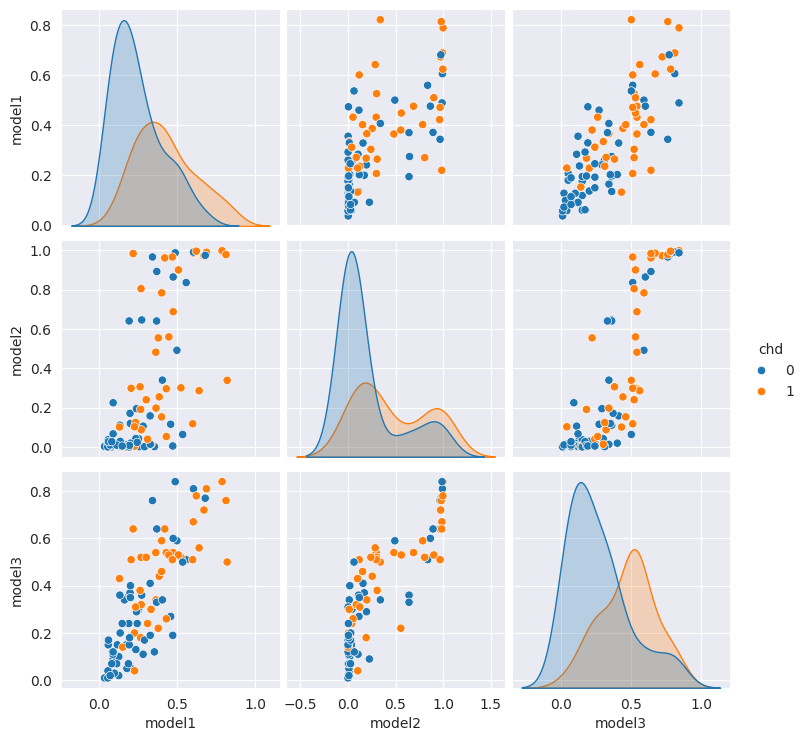

In [10]:
# prompt: para el dataframe df_val quiero hacer un sns pairplot frente a la target y_val

import pandas as pd
import matplotlib.pyplot as plt
# Concatenate y_val to df_val for the pairplot
df_val_plot = pd.concat([df_val, y_val.reset_index(drop=True)], axis=1)

# Create the pairplot
sns.pairplot(df_val_plot, hue="chd", diag_kind="kde")
plt.show()


          model1    model2    model3
model1  1.000000  0.674158  0.788253
model2  0.674158  1.000000  0.845938
model3  0.788253  0.845938  1.000000


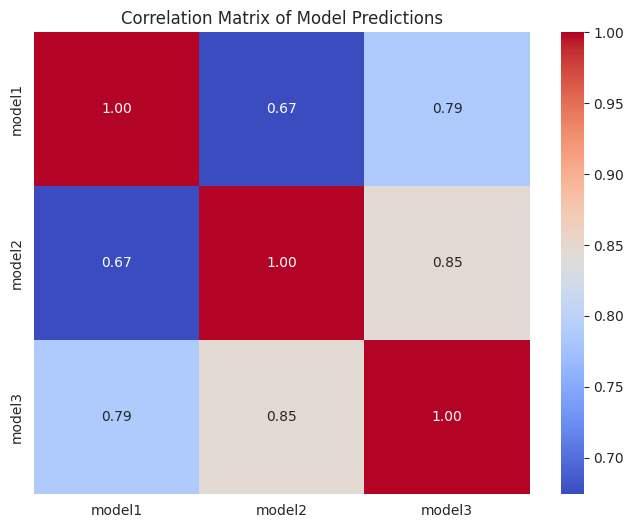

In [11]:
# prompt: correlacion entre model1, model2, model3

import matplotlib.pyplot as plt
# Calculate the correlation matrix
correlation_matrix = df_val.corr()

# Display the correlation matrix
print(correlation_matrix)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Model Predictions')
plt.show()


In [12]:
# prompt: QUITAR DE DF_VAL Y DE DF_TEST LA VARIABLE MODEL 3

df_val = df_val.drop(columns=['model3'])
df_test = df_test.drop(columns=['model3'])


In [13]:
#### stacking stacking stacking !!!!!!!!
# making the final model using the meta features
final_model = LogisticRegression()
final_model.fit(df_val, y_val)

# getting the final output
final_pred = final_model.predict(df_test)

print(classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)

              precision    recall  f1-score   support

           0       0.75      0.87      0.81        31
           1       0.64      0.44      0.52        16

    accuracy                           0.72        47
   macro avg       0.69      0.65      0.66        47
weighted avg       0.71      0.72      0.71        47

[[27  4]
 [ 9  7]]
accuracy 0.723404255319149


In [ ]:
from sklearn.ensemble import StackingClassifier
# Inicializar los modelos base
model_1 = RandomForestClassifier(random_state=42)
model_2 = LogisticRegression(random_state=42)
model_3 = SVC(probability=True)


# putting all base model objects in one list
all_models = [('rf', model_1), ('lr', model_2), ('SVC', model_3)]


# Inicializar el modelo de stacking
#stacking_model = StackingClassifier(
#    estimators=[('rf', model_1), ('lr', model_2), ('knn', model_3)],
#    final_estimator=SVC(kernel='linear', probability=True)
#)

In [ ]:
stacking_model = StackingClassifier(
    all_models,
    final_estimator=SVC(kernel='linear', probability=True)
)
stacking_model

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('lr', LogisticRegression(random_state=42)),
                               ('SVC', SVC(probability=True))],
                   final_estimator=SVC(kernel='linear', probability=True))

In [ ]:
stacking_model.fit(X_train, y_train)
coefficients = stacking_model.final_estimator_.coef_
intercept = stacking_model.final_estimator_.intercept_


In [ ]:
print(coefficients)
print(intercept)

[[-0.47  2.08  2.02]]
[-1.85]


NO ME GUSTAN MUCHO ESOS NUMEROS


In [ ]:
# Obtener las características metaaprendidas por cada clasificador base
X_train_meta = stacking_model.transform(X_train)

In [ ]:
display(X_train_meta)

array([[0.66, 0.2 , 0.19],
       [0.03, 0.18, 0.23],
       [0.14, 0.04, 0.23],
       [0.13, 0.29, 0.23],
       [0.04, 0.15, 0.18],
       [0.84, 0.56, 0.7 ],
       [0.13, 0.44, 0.23],
       [0.29, 0.72, 0.55],
       [0.15, 0.31, 0.23],
       [0.83, 0.71, 0.77],
       [0.27, 0.41, 0.28],
       [0.18, 0.66, 0.27],
       [0.04, 0.06, 0.23],
       [0.8 , 0.79, 0.73],
       [0.1 , 0.16, 0.23],
       [0.79, 0.64, 0.7 ],
       [0.15, 0.22, 0.21],
       [0.59, 0.15, 0.22],
       [0.04, 0.06, 0.22],
       [0.19, 0.53, 0.43],
       [0.05, 0.05, 0.23],
       [0.75, 0.83, 0.7 ],
       [0.08, 0.35, 0.23],
       [0.04, 0.05, 0.23],
       [0.08, 0.06, 0.2 ],
       [0.01, 0.12, 0.22],
       [0.75, 0.14, 0.17],
       [0.08, 0.16, 0.19],
       [0.03, 0.03, 0.23],
       [0.03, 0.04, 0.2 ],
       [0.78, 0.44, 0.35],
       [0.11, 0.36, 0.21],
       [0.74, 0.42, 0.41],
       [0.03, 0.22, 0.2 ],
       [0.14, 0.3 , 0.23],
       [0.79, 0.56, 0.65],
       [0.13, 0.41, 0.23],
 

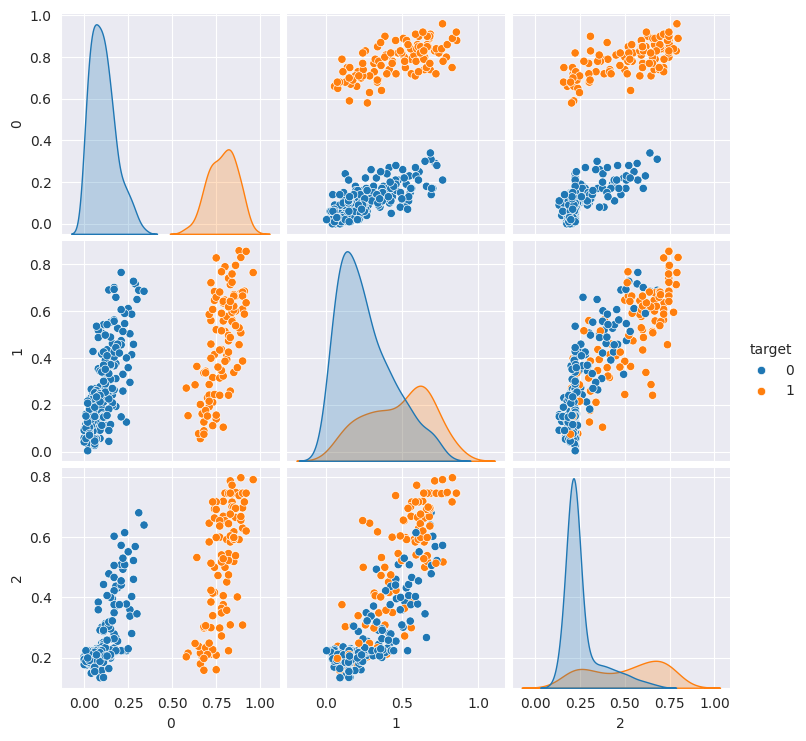

In [ ]:
# prompt: quiero dibujar sns los datos X_train_meta contra la variable target y_train con un pairplot

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir X_train_meta a un DataFrame para facilitar el uso de pairplot
X_train_meta_df = pd.DataFrame(X_train_meta)

# Agregar la columna target al DataFrame
X_train_meta_df['target'] = y_train.values

# Crear el pairplot
sns.pairplot(X_train_meta_df, hue='target', diag_kind='kde')
plt.show()


              precision    recall  f1-score   support

           0       0.71      0.91      0.80        86
           1       0.72      0.40      0.51        53

    accuracy                           0.71       139
   macro avg       0.72      0.65      0.65       139
weighted avg       0.71      0.71      0.69       139



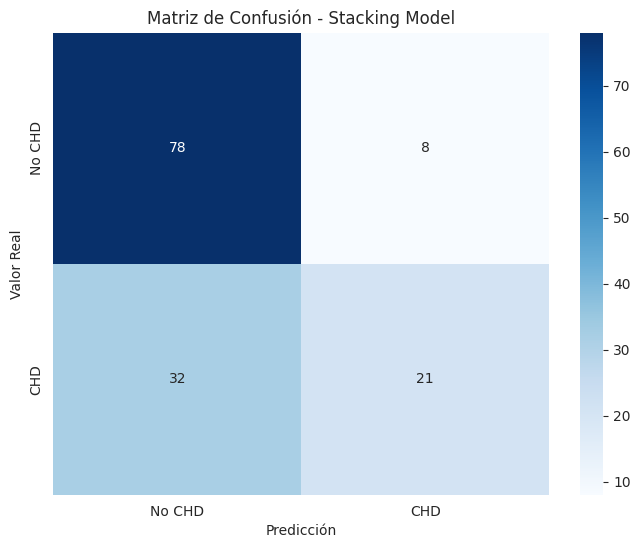

In [ ]:
# Entrenar el modelo de stacking
stacking_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = stacking_model.predict(X_test)

# Mostrar el classification report
print(classification_report(y_test, y_pred))

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión como un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Stacking Model')
plt.show()


¿
HA MERECIDO LA PENA?



Resultados del Clasificador Base rf:
              precision    recall  f1-score   support

           0       0.70      0.86      0.77        86
           1       0.65      0.42      0.51        53

    accuracy                           0.69       139
   macro avg       0.68      0.64      0.64       139
weighted avg       0.68      0.69      0.67       139



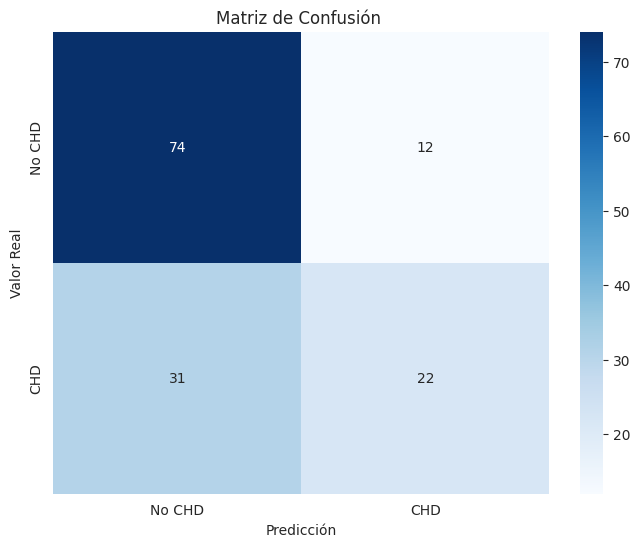


Resultados del Clasificador Base lr:
              precision    recall  f1-score   support

           0       0.70      0.91      0.79        86
           1       0.71      0.38      0.49        53

    accuracy                           0.71       139
   macro avg       0.71      0.64      0.64       139
weighted avg       0.71      0.71      0.68       139



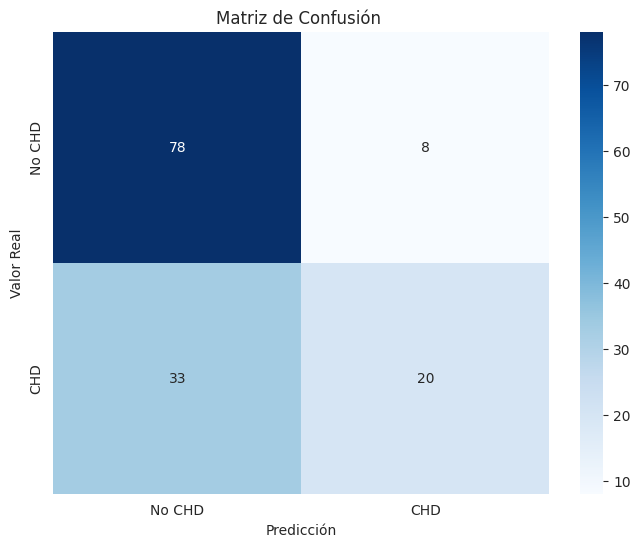


Resultados del Clasificador Base knn:
              precision    recall  f1-score   support

           0       0.69      0.90      0.78        86
           1       0.67      0.34      0.45        53

    accuracy                           0.68       139
   macro avg       0.68      0.62      0.61       139
weighted avg       0.68      0.68      0.65       139



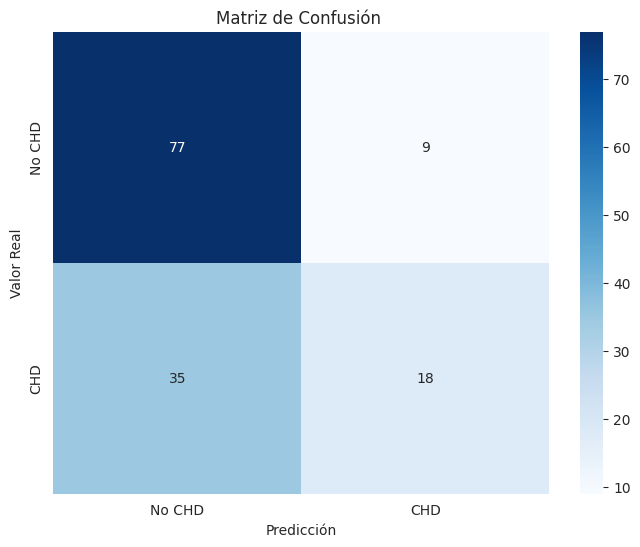

In [ ]:
# Obtener los clasificadores internos
base_classifiers = stacking_model.estimators_

# Obtener las características metaaprendidas por cada clasificador base
X_train_meta = stacking_model.transform(X_train)

# Evaluar el rendimiento de cada clasificador base individualmente
for (name, clf) in stacking_model.named_estimators_.items():
    clf.fit(X_train, y_train)
    y_pred_base = clf.predict(X_test)
    print(f"\nResultados del Clasificador Base {name}:")
    print(classification_report(y_test, y_pred_base))
    #print(f"Accuracy del Clasificador Base {name}: {accuracy_score(y_test, y_pred_base)}")
    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test, y_pred_base)
    # Mostrar la matriz de confusión como un heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión ')
    plt.show()


POR POCO PERO EL STACKING HA MEJORADO LOS MODELOS ANTERIORES



Resultados del Clasificador Base EN TRAIN rf:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       107

    accuracy                           1.00       323
   macro avg       1.00      1.00      1.00       323
weighted avg       1.00      1.00      1.00       323



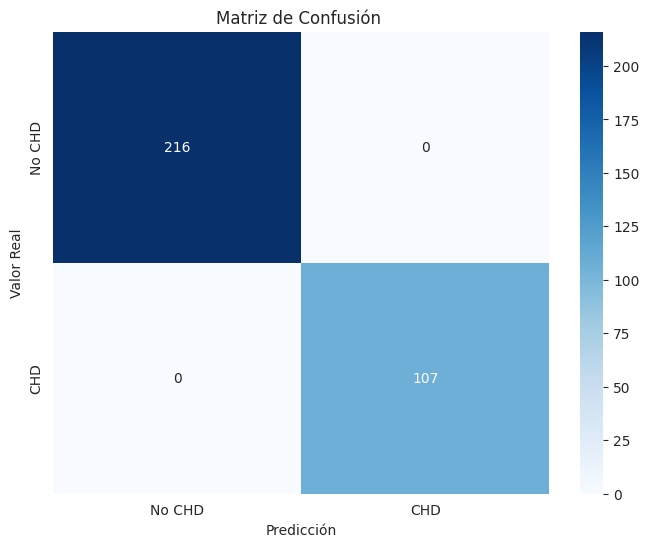


Resultados del Clasificador Base EN TRAIN lr:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       216
           1       0.67      0.52      0.59       107

    accuracy                           0.76       323
   macro avg       0.73      0.70      0.71       323
weighted avg       0.75      0.76      0.75       323



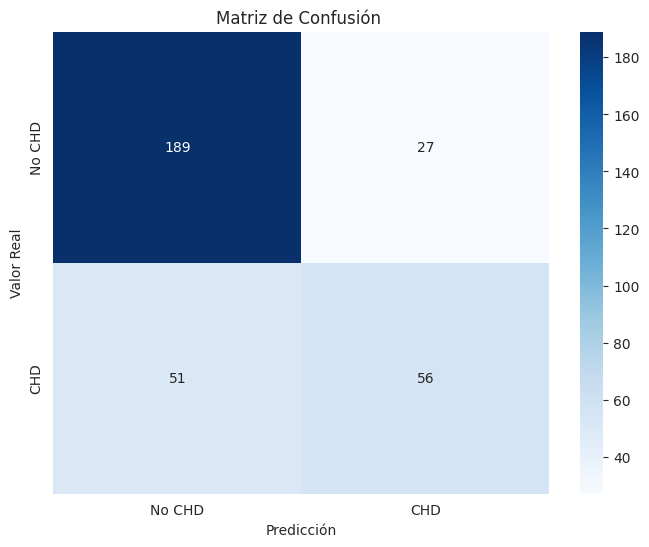


Resultados del Clasificador Base EN TRAIN knn:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       216
           1       0.76      0.57      0.65       107

    accuracy                           0.80       323
   macro avg       0.79      0.74      0.76       323
weighted avg       0.79      0.80      0.79       323



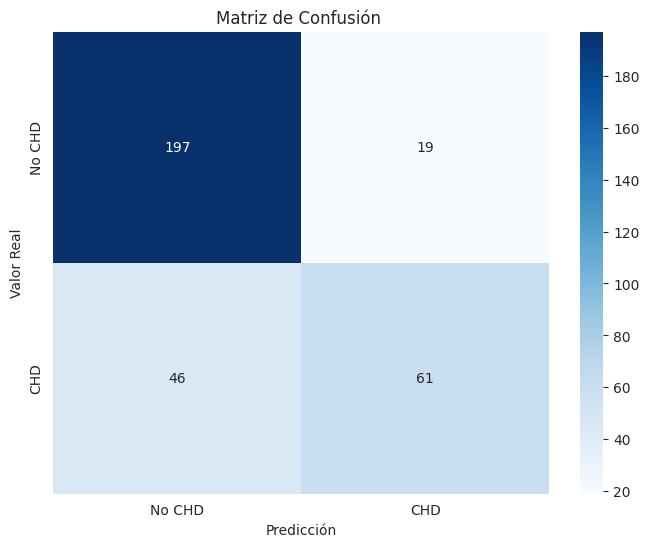

In [ ]:
# Obtener los clasificadores internos
base_classifiers = stacking_model.estimators_

# Obtener las características metaaprendidas por cada clasificador base
X_train_meta = stacking_model.transform(X_train)

# Evaluar el rendimiento de cada clasificador base individualmente
for (name, clf) in stacking_model.named_estimators_.items():
    clf.fit(X_train, y_train)
    y_pred_base = clf.predict(X_train)
    print(f"\nResultados del Clasificador Base EN TRAIN {name}:")
    print(classification_report(y_train, y_pred_base))
    #print(f"Accuracy del Clasificador Base {name}: {accuracy_score(y_test, y_pred_base)}")
    # Calcular la matriz de confusión
    cm = confusion_matrix(y_train, y_pred_base)
    # Mostrar la matriz de confusión como un heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión ')
    plt.show()

In [ ]:
stacking_model = StackingClassifier(
    estimators=[('lr', model_2), ('knn', model_3)],
    final_estimator=SVC(kernel='linear', probability=True)
)

stacking_model.fit(X_train, y_train)
coefficients = stacking_model.final_estimator_.coef_
intercept = stacking_model.final_estimator_.intercept_

print(coefficients)
print(intercept)

[[3.08 0.16]]
[-1.71]


              precision    recall  f1-score   support

           0       0.70      0.91      0.79        86
           1       0.71      0.38      0.49        53

    accuracy                           0.71       139
   macro avg       0.71      0.64      0.64       139
weighted avg       0.71      0.71      0.68       139



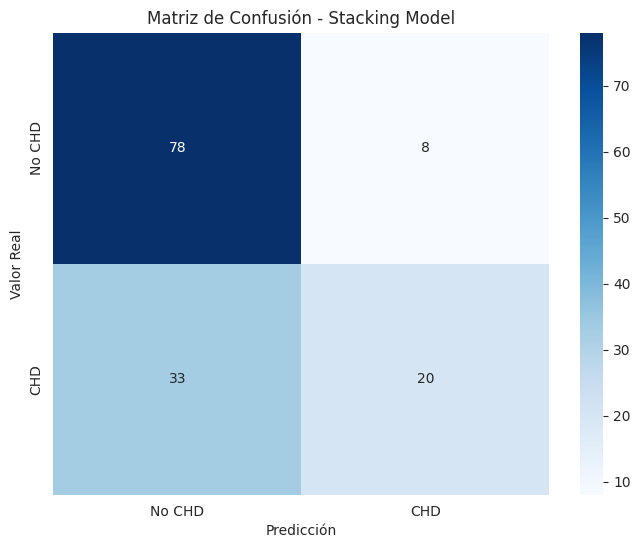

In [ ]:

# Realizar predicciones en el conjunto de prueba
y_pred = stacking_model.predict(X_test)

# Mostrar el classification report
print(classification_report(y_test, y_pred))

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión como un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Stacking Model')
plt.show()


Resultados del Clasificador Base lr:
              precision    recall  f1-score   support

           0       0.70      0.91      0.79        86
           1       0.71      0.38      0.49        53

    accuracy                           0.71       139
   macro avg       0.71      0.64      0.64       139
weighted avg       0.71      0.71      0.68       139



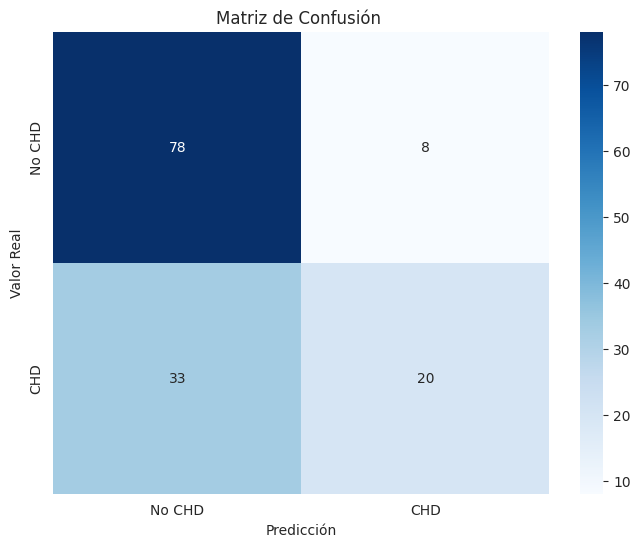


Resultados del Clasificador Base knn:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        86
           1       0.53      0.36      0.43        53

    accuracy                           0.63       139
   macro avg       0.60      0.58      0.58       139
weighted avg       0.62      0.63      0.61       139



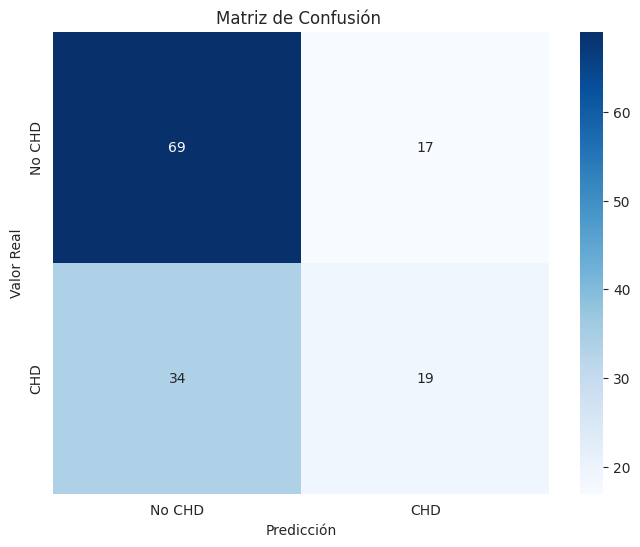

In [ ]:
# Obtener los clasificadores internos
base_classifiers = stacking_model.estimators_

# Obtener las características metaaprendidas por cada clasificador base
X_train_meta = stacking_model.transform(X_train)

# Evaluar el rendimiento de cada clasificador base individualmente
for (name, clf) in stacking_model.named_estimators_.items():
    clf.fit(X_train, y_train)
    y_pred_base = clf.predict(X_test)
    print(f"\nResultados del Clasificador Base {name}:")
    print(classification_report(y_test, y_pred_base))
    #print(f"Accuracy del Clasificador Base {name}: {accuracy_score(y_test, y_pred_base)}")
    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test, y_pred_base)
    # Mostrar la matriz de confusión como un heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión ')
    plt.show()

In [ ]:

### MODELOS ##

models = []
models.append(('LR', LogisticRegression(random_state=seed)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('DTC', DecisionTreeClassifier(random_state=seed)))
models.append(('NB', GaussianNB()))
models.append(('RFC', RandomForestClassifier(random_state=seed)))
models.append(('SVM', SVC(probability=True)))

###############

results = []
names = []
prediciones_train = []
prediccion_test = []
prediccion_train = []

#name='SVM'
#model=SVC(probability=True)
for name, model in models:

    pipeline = make_pipeline(model) ## en realidad no hacemos nada de pipeline pero lo dejo preparado
    pipeline.fit(X_train,y_train)
    aux_test=pipeline.predict_proba(X_test)[:,1] ## me quedo con la probabilidad del si
    aux_test=pd.DataFrame(aux_test, columns=[name])

    aux_train=pipeline.predict_proba(X_train)[:,1] ## me quedo con la probabilidad del si
    aux_train=pd.DataFrame(aux_train, columns=[name])


    prediccion_test.append(aux_test)
    prediccion_train.append(aux_train)

    accuracy=pipeline.score(X_test, y_test)
   # kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
   #cv_results = cross_val_score(pipeline, X, y, cv=kfold, scoring='accuracy')
    results.append(accuracy)
    names.append(name)
print('Resultados', results)
# Concatenar las predicciones originales
predicciones_test = pd.concat(prediccion_test, axis=1)
display(predicciones_test)

predicciones_train = pd.concat(prediccion_train, axis=1)
#display(clasificadores_originales_train)

Resultados [0.7050359712230215, 0.7266187050359713, 0.6330935251798561, 0.6762589928057554, 0.7482014388489209, 0.6690647482014388, 0.6834532374100719]


,LR,LDA,KNN,DTC,NB,RFC,SVM
0,0.495257,0.502592,0.2,0.0,0.544322,0.40,0.295984
1,0.063438,0.068819,0.0,0.0,0.002450,0.06,0.170437
2,0.103324,0.105140,0.0,0.0,0.002087,0.14,0.193764
3,0.329588,0.367912,0.2,1.0,0.924842,0.37,0.434018
4,0.715236,0.754218,1.0,1.0,0.990669,0.82,0.817269
...,...,...,...,...,...,...,...
134,0.189118,0.175924,0.6,0.0,0.067349,0.28,0.247868
135,0.052685,0.055114,0.0,0.0,0.001430,0.05,0.206898
136,0.114398,0.131053,0.0,0.0,0.006702,0.08,0.192401
137,0.413846,0.373042,0.2,0.0,0.348740,0.31,0.251195


In [ ]:
cv_results = []


for name, model in models:
  pipeline = make_pipeline(model)
  kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
  cv_result = cross_val_score(pipeline, X, y, cv=kfold, scoring='accuracy')
  cv_results.append(cv_result)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_result.mean(), cv_result.std())
  print(msg)
print('CV Resultados', cv_results)

LR: 0.724838 (0.056849)
LDA: 0.735661 (0.053981)
KNN: 0.620953 (0.080127)
DTC: 0.640333 (0.072479)
NB: 0.709806 (0.056626)
RFC: 0.662211 (0.065898)
SVM: 0.701156 (0.061835)
CV Resultados [array([0.81, 0.77, 0.76, 0.7 , 0.72, 0.72, 0.7 , 0.65, 0.8 , 0.63]), array([0.83, 0.77, 0.74, 0.7 , 0.72, 0.72, 0.72, 0.7 , 0.83, 0.65]), array([0.68, 0.68, 0.67, 0.7 , 0.57, 0.65, 0.5 , 0.5 , 0.72, 0.54]), array([0.81, 0.64, 0.7 , 0.65, 0.57, 0.61, 0.7 , 0.59, 0.57, 0.59]), array([0.77, 0.72, 0.8 , 0.74, 0.7 , 0.72, 0.67, 0.63, 0.74, 0.61]), array([0.68, 0.7 , 0.83, 0.63, 0.63, 0.61, 0.65, 0.61, 0.7 , 0.59]), array([0.7 , 0.77, 0.74, 0.72, 0.67, 0.74, 0.61, 0.65, 0.8 , 0.61])]


           LR       LDA       KNN       DTC        NB       RFC       SVM
LR   1.000000  0.996674  0.633952  0.472901  0.866567  0.600604  0.836088
LDA  0.996674  1.000000  0.629540  0.472589  0.875353  0.600718  0.840705
KNN  0.633952  0.629540  1.000000  0.574352  0.632706  0.662399  0.727485
DTC  0.472901  0.472589  0.574352  1.000000  0.421934  0.971963  0.636664
NB   0.866567  0.875353  0.632706  0.421934  1.000000  0.550672  0.816349
RFC  0.600604  0.600718  0.662399  0.971963  0.550672  1.000000  0.736086
SVM  0.836088  0.840705  0.727485  0.636664  0.816349  0.736086  1.000000


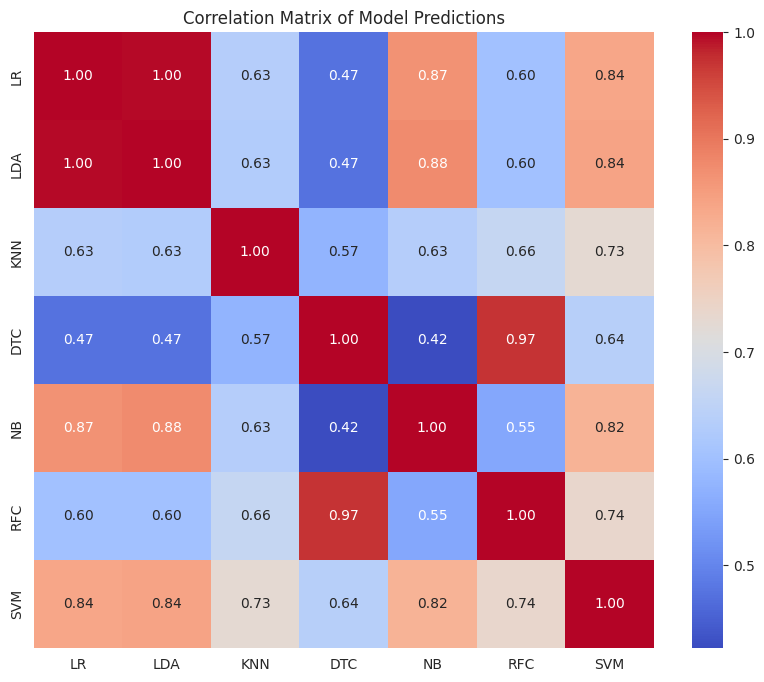

In [ ]:
# prompt: para las prediciones que tenemos hechas con cada modelo quiero hacer un analisis de correlaciones parar decidir como hacer el esemble

import pandas as pd
import matplotlib.pyplot as plt


# Calculate the correlation matrix
correlation_matrix = predicciones_train.corr()

# Display the correlation matrix
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Model Predictions')
plt.show()


In [ ]:
##esembles ####

### ensemble basico
## agregamos las probabilidades de los diferentes algoritmos para ver potencialmente

predicciones_test['ensemble1'] = (predicciones_test['LR'] + predicciones_test['LDA'])/2
predicciones_test['ensemble2'] = (predicciones_test['LR'] + predicciones_test['KNN'])/2
predicciones_test['ensemble3'] = (predicciones_test['LR'] + predicciones_test['DTC'])/2
predicciones_test['ensemble4'] = (predicciones_test['LR'] + predicciones_test['NB'])/2
predicciones_test['ensemble5'] = (predicciones_test['LR'] + predicciones_test['RFC'])/2
predicciones_test['ensemble6'] = (predicciones_test['LR'] + predicciones_test['SVM'])/2
predicciones_test['ensemble7'] = (predicciones_test['LR'] + predicciones_test['NB'] +  predicciones_test['KNN'])/3

# Select the relevant columns for the calculation
original_models = ['LR', 'LDA', 'KNN', 'DTC', 'NB', 'RFC', 'SVM']

# Calculate the maximum and minimum values for each row
predicciones_test['ensemble8'] = predicciones_test[original_models].max(axis=1)
predicciones_test['ensemble9'] = predicciones_test[original_models].min(axis=1)



In [ ]:
display(predicciones_test.head())

,LR,LDA,KNN,DTC,NB,RFC,SVM,ensemble1,ensemble2,ensemble3,ensemble4,ensemble5,ensemble6,ensemble7
0,0.495257,0.502592,0.2,0.0,0.544322,0.40,0.296462,0.498925,0.347628,0.247628,0.519789,0.447628,0.395859,0.413193
1,0.063438,0.068819,0.0,0.0,0.002450,0.06,0.176319,0.066129,0.031719,0.031719,0.032944,0.061719,0.119879,0.021963
2,0.103324,0.105140,0.0,0.0,0.002087,0.14,0.198901,0.104232,0.051662,0.051662,0.052705,0.121662,0.151112,0.035137
3,0.329588,0.367912,0.2,1.0,0.924842,0.37,0.426677,0.348750,0.264794,0.664794,0.627215,0.349794,0.378132,0.484810
4,0.715236,0.754218,1.0,1.0,0.990669,0.82,0.797724,0.734727,0.857618,0.857618,0.852952,0.767618,0.756480,0.901968


In [ ]:

predicciones_test['y_test'] = y_test.iloc[:, 0].values  # Usar .values para evitar problemas de índice

display(predicciones_test)






,LR,LDA,KNN,DTC,NB,RFC,SVM,ensemble1,ensemble2,ensemble3,ensemble4,ensemble5,ensemble6,ensemble7,max_prediction,min_prediction,ensemble8,ensemble9,y_test
0,0.495257,0.502592,0.2,0.0,0.544322,0.40,0.296462,0.498925,0.347628,0.247628,0.519789,0.447628,0.395859,0.413193,0.544322,0.000000,0.544322,0.000000,1
1,0.063438,0.068819,0.0,0.0,0.002450,0.06,0.176319,0.066129,0.031719,0.031719,0.032944,0.061719,0.119879,0.021963,0.176319,0.000000,0.176319,0.000000,0
2,0.103324,0.105140,0.0,0.0,0.002087,0.14,0.198901,0.104232,0.051662,0.051662,0.052705,0.121662,0.151112,0.035137,0.198901,0.000000,0.198901,0.000000,0
3,0.329588,0.367912,0.2,1.0,0.924842,0.37,0.426677,0.348750,0.264794,0.664794,0.627215,0.349794,0.378132,0.484810,1.000000,0.200000,1.000000,0.200000,1
4,0.715236,0.754218,1.0,1.0,0.990669,0.82,0.797724,0.734727,0.857618,0.857618,0.852952,0.767618,0.756480,0.901968,1.000000,0.715236,1.000000,0.715236,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.189118,0.175924,0.6,0.0,0.067349,0.28,0.250763,0.182521,0.394559,0.094559,0.128233,0.234559,0.219940,0.285489,0.600000,0.000000,0.600000,0.000000,0
135,0.052685,0.055114,0.0,0.0,0.001430,0.05,0.211550,0.053900,0.026343,0.026343,0.027058,0.051343,0.132118,0.018038,0.211550,0.000000,0.211550,0.000000,0
136,0.114398,0.131053,0.0,0.0,0.006702,0.08,0.197585,0.122726,0.057199,0.057199,0.060550,0.097199,0.155992,0.040367,0.197585,0.000000,0.197585,0.000000,0
137,0.413846,0.373042,0.2,0.0,0.348740,0.31,0.253934,0.393444,0.306923,0.206923,0.381293,0.361923,0.333890,0.320862,0.413846,0.000000,0.413846,0.000000,0


In [ ]:
#Resultados_finales = Resultados_finales.drop(columns=['y_test']) ## ahora la quito para binarizar

Resultados_finales=predicciones_test.drop(columns=['y_test'])

from sklearn.preprocessing import Binarizer

transformer = Binarizer(threshold=0.5).fit(Resultados_finales)  # fit does nothing.
predicciones_ensemble=pd.DataFrame(transformer.transform(Resultados_finales))

predicciones_ensemble['y_test'] = y_test.iloc[:, 0].values  # Usar .values para evitar problemas de índice

display(predicciones_ensemble)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,y_test
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
137,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
## ponemos el test solo para ver que esta ocurriendo

In [ ]:


# Calculamos las curvas ROC y accuracy de los ensembles

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

y_test.replace(('Si', 'No'), (1, 0), inplace=True)

accuracy_esemble=[]

for k in range(18):
  cm = confusion_matrix(y_test.iloc[:,0], predicciones_ensemble.iloc[:,k])
  accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
 # print('La precision para el clasificador' ,k+1, 'es', accuracy )
  print('El area bajo la curva para clasificador es' , k+1, 'es', roc_auc_score(y_test, predicciones_ensemble.iloc[:,k]))
  accuracy_esemble.append(accuracy)

#accuracy_esemble = pd.concat(accuracy_esemble, axis=1)
display(accuracy_esemble)


El area bajo la curva para clasificador es 1 es 0.6421676173760421
El area bajo la curva para clasificador es 2 es 0.670469504168495
El area bajo la curva para clasificador es 3 es 0.5804080737165423
El area bajo la curva para clasificador es 4 es 0.6478718736287845
El area bajo la curva para clasificador es 5 es 0.7277314611671786
El area bajo la curva para clasificador es 6 es 0.6094778411584028
El area bajo la curva para clasificador es 7 es 0.5986178148310662
El area bajo la curva para clasificador es 8 es 0.6610355419043441
El area bajo la curva para clasificador es 9 es 0.6305397103992979
El area bajo la curva para clasificador es 10 es 0.6478718736287845
El area bajo la curva para clasificador es 11 es 0.7132514260640631
El area bajo la curva para clasificador es 12 es 0.63635366388767
El area bajo la curva para clasificador es 13 es 0.6421676173760421
El area bajo la curva para clasificador es 14 es 0.6755155770074593
El area bajo la curva para clasificador es 15 es 0.727621763

[0.7050359712230215,
 0.7266187050359713,
 0.6330935251798561,
 0.6762589928057554,
 0.7482014388489209,
 0.6690647482014388,
 0.6690647482014388,
 0.7194244604316546,
 0.6906474820143885,
 0.6762589928057554,
 0.7482014388489209,
 0.697841726618705,
 0.7050359712230215,
 0.7194244604316546,
 0.7122302158273381,
 0.6330935251798561,
 0.7122302158273381,
 0.6330935251798561]